In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

# Ganti ini dengan path sebenarnya ke file .zip Anda di Google Drive
zip_file_path = '/content/drive/MyDrive/Pneunomia/dataset_pneunomia.zip'

# Ganti ini dengan folder tujuan tempat Anda ingin mengekstrak file
destination_folder = '/content/extracted_images'

# Buat folder tujuan jika belum ada
!mkdir -p {destination_folder}

# Mengekstrak file .zip
!unzip -q {zip_file_path} -d {destination_folder}

print(f"File berhasil diekstrak ke: {destination_folder}")

# Anda bisa memeriksa isinya (opsional)
!ls {destination_folder}

Mounted at /content/drive
File berhasil diekstrak ke: /content/extracted_images
chest_xray


### 1. Ekstraksi Fitur Menggunakan Model Pra-terlatih (VGG16)

Kita akan menggunakan model VGG16 yang telah dilatih pada dataset ImageNet. Kita akan membuang lapisan klasifikasi terakhir dan menggunakan lapisan-lapisan sebelumnya untuk mengekstrak fitur berdimensi tinggi dari gambar-gambar X-ray.

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Tentukan ukuran gambar yang diharapkan oleh VGG16
IMG_WIDTH, IMG_HEIGHT = 224, 224

# Memuat model VGG16 pra-terlatih tanpa lapisan klasifikasi teratas
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

# Buat model baru yang hanya memiliki lapisan ekstraksi fitur
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

print("Model VGG16 sebagai feature extractor berhasil dimuat.")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model VGG16 sebagai feature extractor berhasil dimuat.


### Fungsi untuk Ekstraksi Fitur dari Direktori Gambar

Kita akan membuat fungsi pembantu untuk memuat gambar dari direktori dan mengekstrak fiturnya menggunakan `feature_extractor` yang telah kita definisikan.

In [ ]:
def extract_features(directory, model):
    features = []
    filenames = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(root, file)
                try:
                    img = image.load_img(img_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
                    img_array = image.img_to_array(img)
                    img_array = np.expand_dims(img_array, axis=0) # Tambahkan dimensi batch
                    img_array = preprocess_input(img_array) # Preprocessing sesuai VGG16

                    feature = model.predict(img_array, verbose=0) # Ekstrak fitur
                    features.append(feature.flatten()) # Ratakan fitur ke 1D
                    filenames.append(img_path)
                except Exception as e:
                    print(f"Gagal memproses gambar {img_path}: {e}")
    return np.array(features), filenames

# Path ke folder dataset (gunakan path yang sama dengan ekstraksi zip)
base_dir = destination_folder
chest_xray_dir = os.path.join(base_dir, 'chest_xray')

# Kita akan mengekstrak fitur HANYA dari gambar PNEUMONIA untuk clustering
all_images_dir = [
    os.path.join(chest_xray_dir, 'train', 'PNEUMONIA'),
    os.path.join(chest_xray_dir, 'val', 'PNEUMONIA'),
    os.path.join(chest_xray_dir, 'test', 'PNEUMONIA')
]

all_features = []
all_filenames = []

print("Memulai ekstraksi fitur dari semua gambar PNEUMONIA...")
for folder in all_images_dir:
    print(f"Ekstraksi fitur dari {folder}...")
    current_features, current_filenames = extract_features(folder, feature_extractor)
    all_features.extend(current_features)
    all_filenames.extend(current_filenames)

all_features = np.array(all_features)

print(f"\nTotal fitur yang diekstraksi: {all_features.shape}")
print(f"Total gambar yang diproses: {len(all_filenames)}")

Memulai ekstraksi fitur dari semua gambar PNEUMONIA...
Ekstraksi fitur dari /content/extracted_images/chest_xray/train/PNEUMONIA...
Ekstraksi fitur dari /content/extracted_images/chest_xray/val/PNEUMONIA...
Ekstraksi fitur dari /content/extracted_images/chest_xray/test/PNEUMONIA...

Total fitur yang diekstraksi: (4273, 25088)
Total gambar yang diproses: 4273


### 2. Dimensionality Reduction (PCA)

Fitur yang diekstrak masih memiliki dimensi yang sangat tinggi. Kita akan menggunakan PCA untuk mengurangi dimensi fitur ini agar lebih mudah untuk di-cluster dan divisualisasikan.

Menerapkan PCA dengan 50 komponen...
Dimensi fitur setelah PCA: (4273, 50)


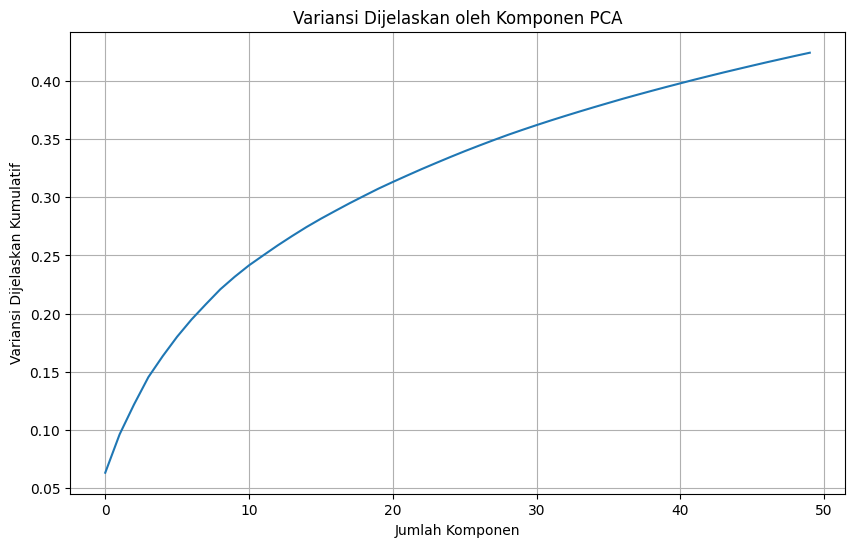

Dari plot di atas, Anda bisa melihat berapa banyak variansi data yang dijelaskan oleh sejumlah komponen PCA.


In [ ]:
from sklearn.decomposition import PCA

# Tentukan jumlah komponen PCA
n_components = 50 # Bisa disesuaikan

print(f"Menerapkan PCA dengan {n_components} komponen...")
pca = PCA(n_components=n_components)
reduced_features = pca.fit_transform(all_features)

print(f"Dimensi fitur setelah PCA: {reduced_features.shape}")

# Visualisasi variansi yang dijelaskan oleh setiap komponen
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Jumlah Komponen')
plt.ylabel('Variansi Dijelaskan Kumulatif')
plt.title('Variansi Dijelaskan oleh Komponen PCA')
plt.grid(True)
plt.show()

print("Dari plot di atas, Anda bisa melihat berapa banyak variansi data yang dijelaskan oleh sejumlah komponen PCA.")

### 3. Clustering Menggunakan K-Means

Sekarang kita akan menerapkan algoritma K-Means pada fitur-fitur yang sudah direduksi dimensinya untuk mengidentifikasi kelompok-kelompok (stadium) yang berbeda dalam data gambar pneumonia.

In [ ]:
from sklearn.cluster import KMeans

# Tentukan jumlah cluster (k) yang ingin Anda identifikasi
# Anda bisa mencoba nilai yang berbeda dan mengevaluasi hasilnya
k = 4 # Mengubah k menjadi 4 sesuai permintaan user

print(f"Menerapkan K-Means dengan {k} cluster...")
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init untuk memastikan konvergensi
clusters = kmeans.fit_predict(reduced_features)

print("Clustering selesai.")

# Menampilkan distribusi ukuran cluster
unique_clusters, counts = np.unique(clusters, return_counts=True)
for cluster_id, count in zip(unique_clusters, counts):
    print(f"Cluster {cluster_id}: {count} gambar")

Menerapkan K-Means dengan 4 cluster...
Clustering selesai.
Cluster 0: 1076 gambar
Cluster 1: 844 gambar
Cluster 2: 1532 gambar
Cluster 3: 821 gambar


### 4. Analisis dan Visualisasi Cluster

Untuk menganalisis hasil clustering, kita bisa mencoba melihat beberapa contoh gambar dari setiap cluster. Ini akan membantu kita memahami karakteristik dari setiap 'stadium' yang diidentifikasi oleh algoritma unsupervised.

### 5. Evaluasi Clustering (Silhouette Score)

Kita akan menggunakan Silhouette Score untuk mengevaluasi kualitas clustering yang telah dilakukan. Silhouette Score mengukur seberapa mirip suatu objek dengan clusternya sendiri dibandingkan dengan cluster lain.

In [ ]:
from sklearn.metrics import silhouette_score

# Pastikan jumlah cluster lebih dari 1 untuk menghitung Silhouette Score
if k > 1:
    print(f"Menghitung Silhouette Score untuk {k} cluster...")
    silhouette_avg = silhouette_score(reduced_features, clusters)
    print(f"Silhouette Score rata-rata: {silhouette_avg:.3f}")

    # Interpretasi Silhouette Score:
    if silhouette_avg > 0.7:
        print("Kualitas clustering sangat baik (objek terpisah jauh dari cluster tetangga).")
    elif silhouette_avg > 0.5:
        print("Kualitas clustering cukup baik (pemisahan yang wajar).")
    elif silhouette_avg > 0.2:
        print("Kualitas clustering sedang (struktur cluster mungkin lemah).")
    else:
        print("Kualitas clustering buruk (cluster mungkin tumpang tindih atau salah bentuk).")
else:
    print("Tidak dapat menghitung Silhouette Score karena jumlah cluster (k) <= 1.")

Menghitung Silhouette Score untuk 4 cluster...
Silhouette Score rata-rata: 0.076
Kualitas clustering buruk (cluster mungkin tumpang tindih atau salah bentuk).


### 5.1 Definisi Nama Kluster (Interpretasi Manual)

Berdasarkan observasi visual dari contoh gambar di setiap kluster, Anda bisa memberikan nama interpretatif untuk setiap kluster. Silakan sesuaikan nama-nama di bawah ini sesuai dengan analisis Anda (misalnya, "Pneumonia Bakterial", "Pneumonia Viral", "Pneumonia Atipikal", dll.).

In [ ]:
# Definisikan mapping nama kluster (sesuaikan nama 'Pneumonia Tipe X' sesuai interpretasi Anda)
cluster_name_mapping = {
    0: 'Pneumonia Tipe Bakterial',
    1: 'Pneumonia Tipe Atipikal',
    2: 'Pneumonia Tipe Viral',
    3: 'Pneumonia Tipe Fungal'
}

# Pastikan semua kluster yang ada terdaftar di mapping
for cluster_id in unique_clusters:
    if cluster_id not in cluster_name_mapping:
        cluster_name_mapping[cluster_id] = f'Kluster {cluster_id} (nama tidak didefinisikan)'

print("Mapping nama kluster berhasil dibuat. Silakan modifikasi nilainya sesuai observasi visual Anda.")

Mapping nama kluster berhasil dibuat. Silakan modifikasi nilainya sesuai observasi visual Anda.



--- Contoh Gambar dari Pneumonia Tipe Bakterial (Cluster 0) ---


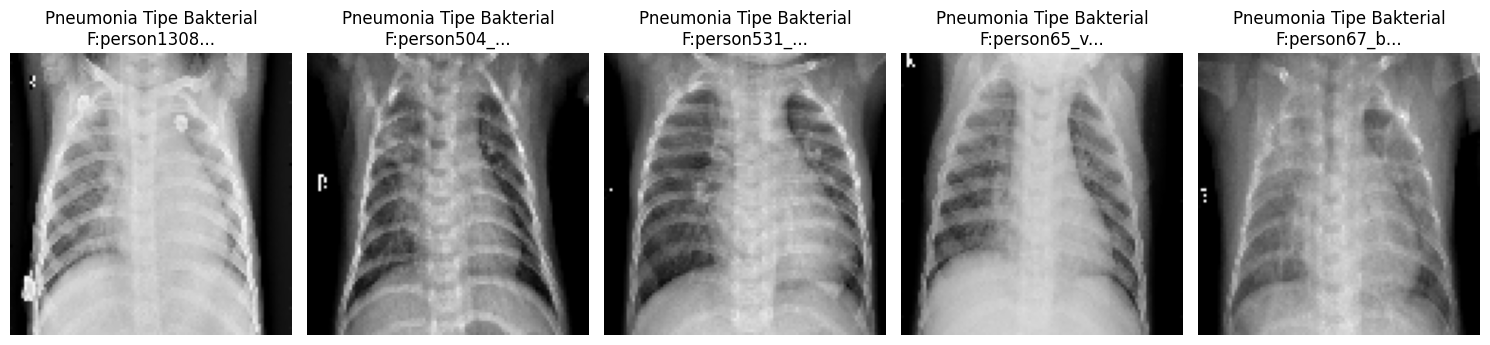


--- Contoh Gambar dari Pneumonia Tipe Atipikal (Cluster 1) ---


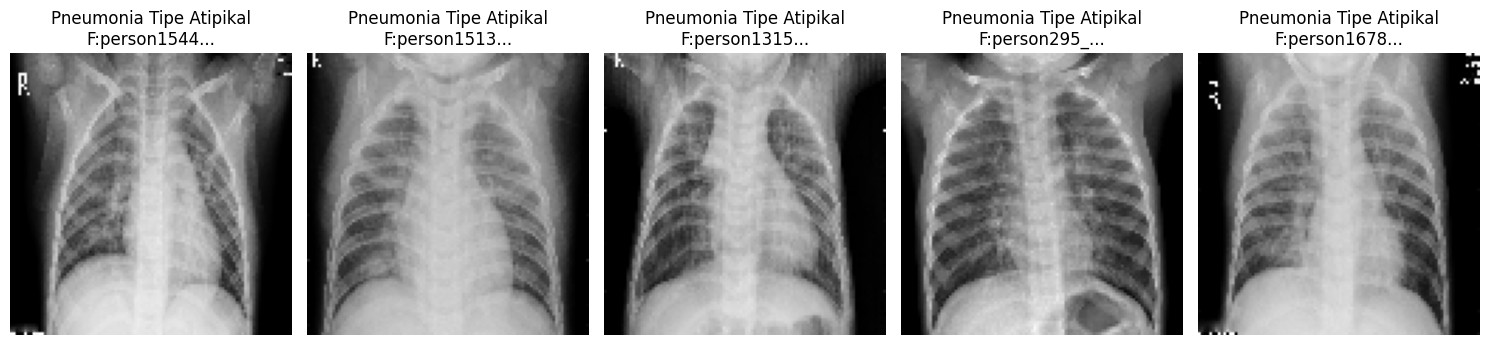


--- Contoh Gambar dari Pneumonia Tipe Viral (Cluster 2) ---


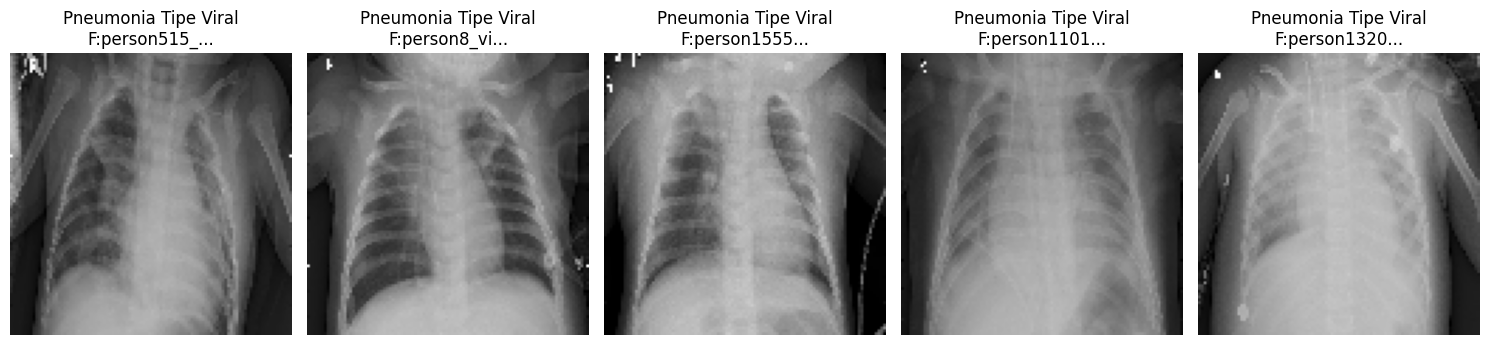


--- Contoh Gambar dari Pneumonia Tipe Fungal (Cluster 3) ---


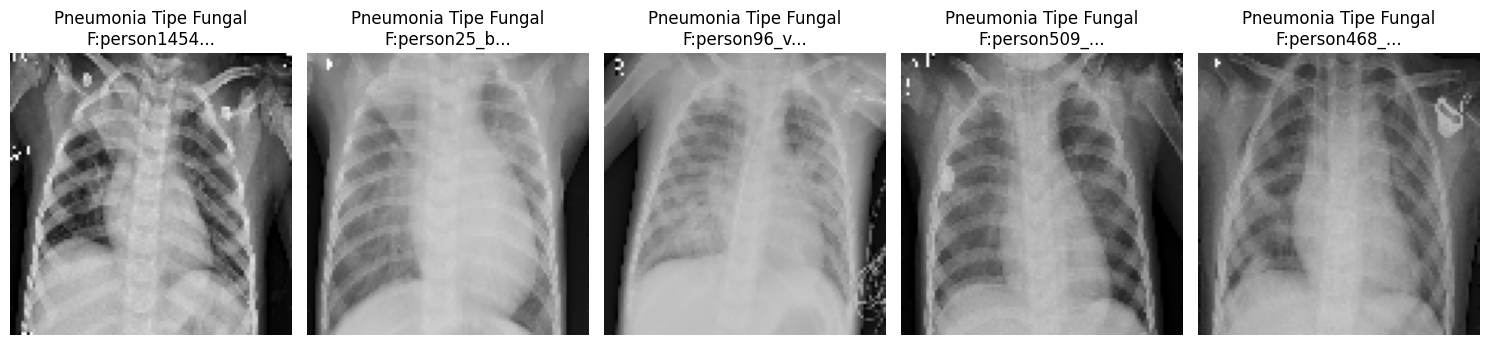

In [ ]:
import random

# Fungsi untuk menampilkan beberapa gambar dari setiap cluster
def display_cluster_images(cluster_id, num_images=5):
    # Gunakan nama kluster dari mapping jika tersedia
    cluster_display_name = cluster_name_mapping.get(cluster_id, f'Cluster {cluster_id}')
    print(f"\n--- Contoh Gambar dari {cluster_display_name} (Cluster {cluster_id}) ---")
    cluster_indices = [i for i, c in enumerate(clusters) if c == cluster_id]

    if not cluster_indices:
        print(f"Tidak ada gambar di Cluster {cluster_id}.")
        return

    # Ambil beberapa gambar secara acak dari cluster ini
    sample_indices = random.sample(cluster_indices, min(num_images, len(cluster_indices)))

    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(sample_indices):
        img_path = all_filenames[idx]
        try:
            img = image.load_img(img_path, target_size=(100, 100)) # Ukuran lebih kecil untuk display
            plt.subplot(1, num_images, i + 1)
            plt.imshow(img)
            plt.title(f"{cluster_display_name}\nF:{os.path.basename(img_path)[:10]}...") # Tampilkan nama cluster dan sebagian nama file
            plt.axis('off')
        except Exception as e:
            print(f"Gagal menampilkan gambar {img_path}: {e}")
    plt.tight_layout()
    plt.show()

# Tampilkan contoh gambar dari setiap cluster yang ditemukan
for i in range(k):
    display_cluster_images(i)

Dari visualisasi ini, Anda dapat mencoba menginterpretasikan apa yang membedakan gambar-gambar di setiap cluster. Misalnya, apakah ada perbedaan tingkat keparahan, pola infiltrasi, atau area yang terpengaruh antara satu cluster dengan yang lain.

Anda juga dapat mencoba:
- Mengubah nilai `k` (jumlah cluster) dan melihat apakah itu menghasilkan pengelompokan yang lebih bermakna.
- Menggunakan algoritma clustering lain (misalnya, DBSCAN).
- Menggunakan teknik visualisasi dimensi rendah seperti t-SNE pada `reduced_features` untuk melihat bagaimana cluster terpisah dalam ruang 2D atau 3D.

### 6. Visualisasi Kluster Menggunakan t-SNE

Untuk mendapatkan gambaran yang lebih baik tentang bagaimana kluster-kluster ini terpisah dalam ruang fitur, kita akan menggunakan t-Distributed Stochastic Neighbor Embedding (t-SNE) untuk mereduksi dimensi `reduced_features` menjadi 2D dan kemudian memvisualisasikannya.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Reduksi dimensi t-SNE selesai.


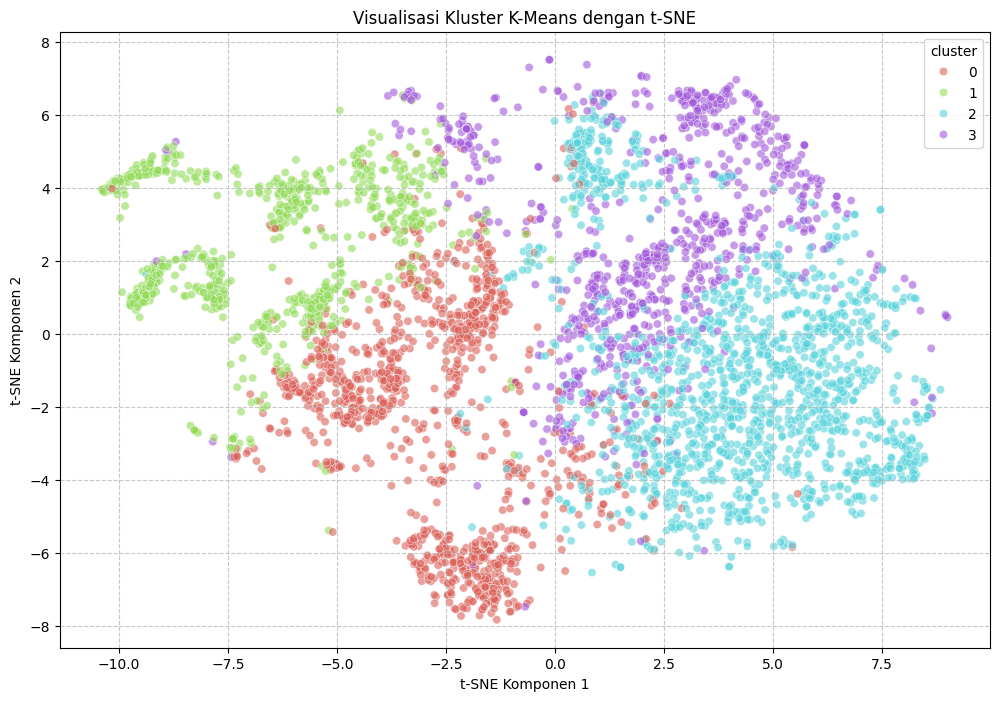

In [ ]:
from sklearn.manifold import TSNE
import pandas as pd
import seaborn as sns

# Reduksi dimensi dengan t-SNE ke 2 komponen
# Anda bisa mencoba nilai perplexity dan n_iter yang berbeda
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
tsne_results = tsne.fit_transform(reduced_features)

print("Reduksi dimensi t-SNE selesai.")

# Buat DataFrame untuk visualisasi
df_tsne = pd.DataFrame(tsne_results, columns=['tsne-2d-one', 'tsne-2d-two'])
df_tsne['cluster'] = clusters

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="cluster",
    palette=sns.color_palette("hls", k),
    data=df_tsne,
    legend="full",
    alpha=0.6
)
plt.title('Visualisasi Kluster K-Means dengan t-SNE')
plt.xlabel('t-SNE Komponen 1')
plt.ylabel('t-SNE Komponen 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import joblib

In [ ]:
# Simpan reduced_features dan clusters ke file .pkl
joblib.dump(reduced_features, os.path.join(project_path, 'reduced_features.pkl'))
joblib.dump(clusters, os.path.join(project_path, 'clusters.pkl'))

['/content/drive/MyDrive/Pneunomia/clusters.pkl']

In [ ]:
print("✅ Both .pkl files have been generated and saved to your Google Drive!")

✅ Both .pkl files have been generated and saved to your Google Drive!


Plot t-SNE di atas menunjukkan bagaimana titik-titik data (gambar) tersebar dalam ruang 2D, diwarnai berdasarkan kluster K-Means yang mereka miliki. Anda dapat mengamati seberapa baik kluster-kluster tersebut terpisah secara visual. Jika ada tumpang tindih yang signifikan, itu mungkin menunjukkan bahwa kluster-kluster tersebut tidak terlalu berbeda atau ada ruang untuk penyesuaian parameter (misalnya, nilai `k` untuk K-Means atau parameter t-SNE).

### 7. Menyimpan Model Feature Extractor

Kita akan menyimpan model `feature_extractor` (VGG16 tanpa lapisan atas) yang telah kita gunakan untuk mengekstrak fitur. Ini berguna agar kita tidak perlu memuat dan menginisialisasi ulang model ini setiap kali kita menjalankan notebook atau jika ingin menggunakannya di tempat lain.

In [ ]:
project_path = '/content/drive/MyDrive/Pneunomia' # Sesuaikan dengan path folder proyek Anda

# Pastikan folder project_path ada
if not os.path.exists(project_path):
    os.makedirs(project_path)
    print(f"Folder {project_path} dibuat.")

final_model_path = os.path.join(project_path, 'vgg16_feature_extractor_pneumonia.keras')

# Simpan model feature_extractor
feature_extractor.save(final_model_path)
print(f"✅ Model Feature Extractor berhasil disimpan di: {final_model_path}")

✅ Model Feature Extractor berhasil disimpan di: /content/drive/MyDrive/Pneunomia/vgg16_feature_extractor_pneumonia.keras


In [ ]:
import pickle

# Save the actual machine learning model engines, not just the arrays!
with open('/content/drive/MyDrive/Pneunomia/pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)

with open('/content/drive/MyDrive/Pneunomia/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

print("✅ Saved the actual model engines as pca_model.pkl and kmeans_model.pkl!")

✅ Saved the actual model engines as pca_model.pkl and kmeans_model.pkl!
